<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lessons/Module_3/Lesson_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 3.3 (Linear Growth Model) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Curve Fitting](#Curve-Fitting)

4.  [Simulation Setup](#Setup)

5.  [Parameter Search](#Search)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Population Data </b> </font>

<p align = 'justify'>
In previous lessons, we noted that models serve three primary purposes: to describe a system, to predict the growth of a system, and to optimize a system.  In this chapter, we'll start with the first purpose. We're going to start with a set of data (world population growth since 1950) and try to build a model that matches the data.  In other words, we want to find the "set of rules" that governs the system.
</p>

<br>

<p align = 'justify'>
<b>data</b> is stored in a DataFrame, which is a data storage object that is made to store tables of data; it is similar to a Series, except that it can have multiple columns.  So much like a Series, data has an index, which in this case is a list of years from 1950 to 2016.  But it has two columns: one holds data that has been estimated by the U.S. Census Bureau, and one holds data gathered by the United Nations. The values are in billions.
</p>

In [ ]:
##=============================================================================================##
## Import Libraries:                                                                           ##
##=============================================================================================##

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display_html
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

##=============================================================================================##
## Import the Data:                                                                            ##
##=============================================================================================##

# Define the file we want to import

address = 'https://github.com/MAugspurger/ModSimPy_MAugs/raw/main/'
file_loc = 'Images_and_Data/Data/World_pop_data.xlsx'

# Import the world population data
data = pd.read_excel(address + file_loc, header=0,index_col=0)

##=============================================================================================##
## Display the Data:                                                                           ##
##=============================================================================================##

display(data.head())

,US_census,UN
Year,,
1950,2.557629,2.525149
1951,2.594940,2.572851
1952,2.636772,2.619292
1953,2.682053,2.665865
1954,2.730228,2.713172


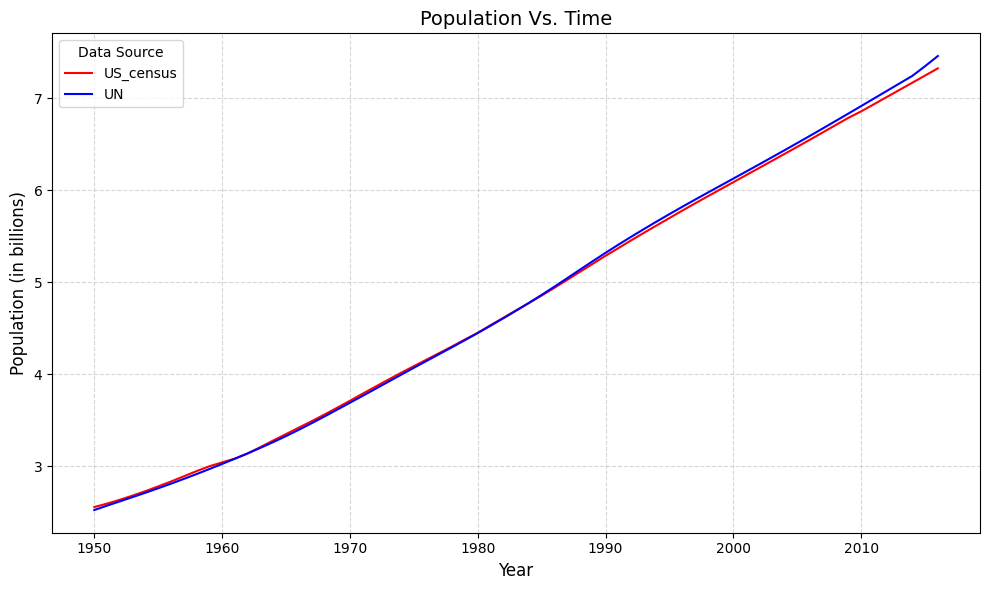

In [ ]:
##=============================================================================================##
## Plot the Data:                                                                              ##
##=============================================================================================##

ax = data.plot(
    kind    = 'line',
    y       = ['US_census', 'UN'],
    color   = ['red', 'blue'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Population Vs. Time", fontsize = 14)

ax.set_xlabel("Year", fontsize = 12)

ax.set_ylabel("Population (in billions)", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha = 0.5)

plt.legend(title = "Data Source")

plt.tight_layout()

# Display the plot:

plt.show()

<center>$\rule$</center>

<font size = 5> <b> 2.2 Define Useful Functions </b> </font>

In [ ]:
#@title This cell defines the functions: display_dataframes, create_model, display_model, and plot_data

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    html_df = pd.DataFrame(df).head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  create_model                                                                     ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def create_model(X, y, name, bias_on = True):

  ##===========================================================================================##
  ## Use a LinearRegression Object to Find the Best Fit for the Model:                         ##
  ##===========================================================================================##

  # Create a LinearRegression object with a forced-origin intercept:

  model = LinearRegression(fit_intercept = bias_on)

  # Fit the LinearRegression objects to the features and target:

  model.fit(X, y)

  # Get the coefficient and bias for the model:

  coefs = np.round(model.coef_[0], 2)
  bias  = np.round(model.intercept_, 2)

  ##===========================================================================================##
  ## Get The Model Predictions:                                                                ##
  ##===========================================================================================##

  predictions = model.predict(X)

  ##===========================================================================================##
  ## Calculate Model Losses:                                                                   ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, predictions))

  ##===========================================================================================##
  ## Create a DataFrame to Store the Model's Results and Predictions:                          ##
  ##===========================================================================================##

  # Create the results DataFrame:

  results_df = pd.DataFrame({"Name": name, "Coefs": [coefs], "Bias": bias, "Loss": loss})

  # Create the predictions DataFrame:

  predictions_df = pd.DataFrame({"Target": X.iloc[:, 0]})

  predictions_df["Predictions"] = predictions

  ##===========================================================================================##
  ## Return the Model's Results and Predictions:                                               ##
  ##===========================================================================================##

  return results_df, predictions_df

##=============================================================================================##
## Function:  display_models                                                                   ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            trunc      - Number of decimals to display for numbers (optional, default = 3)   ##
##            n_items    - Number of items to display (optional, default = 5)                  ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coef_list, bias_list, loss_list, title, trunc = 3, n_items = 5):

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  for i in range (0, len(model_list)):

    coef_list[i] = np.round(coef_list[i], trunc)
    bias_list[i] = np.round(bias_list[i], trunc)
    loss_list[i] = np.round(loss_list[i], trunc)

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coef_list

  # Add the model biases:

  results["Bias"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title], n_items)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(model_list[i]["Target"], model_list[i]["Predictions"], color = color_list[i],
               label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[-1]["Predictions"] + error

    # Create the error- model:

    model_minus_error = model_list[-1]["Predictions"] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': model_list[0]["Target"],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

[Return to Top](#Notebook-Start)

<a name="Curve-Fitting"></a>

---

<font size = 6> <b> 3. Curve Fitting</b> </font>

---

<font size = 5> <b> 3.1 Curve Fitting As Modeling </b> </font>

Now that we've imported the data, we want to try to understand it: we need this understanding in order to decide what kind of model we'll use to predict future growth. In other words, we need to know the 'rules' that population growth follows.

<br>

Curve fitting is one way we can do this.  When we fit a curve, we are trying to determine the mathematical function (that is, the 'rule') that best represents the data.

<br>

From previous lessons, we know that the form of the equation can take many forms(linear, polynomial, exponential, etc...). Curve fitting allows us to understand a key parameter of the system.

<br>

In situations, like world population, we don't always know the type of equation we'll need before hand. So we use curve fitting to help us find the rules: if we can find a curve that matches the data, then we start to better understand the system!

<br>

As usual, we'll start simple and add complexity as we go.  Although there is some curvature in the plotted estimates, it looks like world population growth has been close to linear since 1960 or so.  So we'll start with the assumption that the data behaves in a linear fashion.

<br>

To fit the model to the data, we'll compute the average annual growth
from 1950 to 2016: this will be the slope of our line. Since the UN and Census data are so close, we'll use the Census data.

In [ ]:
##=============================================================================================##
## Clean the Data and Separate Features and Targets:                                           ##
##=============================================================================================##

# Remove any rows missing data:

cleaned_data = data.reset_index().dropna()

# Identify the feature data:

X = pd.DataFrame(cleaned_data["Year"])

# Identify the target data:

y = pd.DataFrame(cleaned_data["US_census"])

##=============================================================================================##
## Display the Full Dataset, Feature Data, and Target Data:                                    ##
##=============================================================================================##

# Display the feature and target data:

display_dataframes([cleaned_data, X, y], ["Full Dataset", "Feature Data", "Target Data"])

Full Dataset 
 
 
 
 Year 
 US_census 
 UN 
 
 
 
 
 0 
 1950 
 2.557629 
 2.525149 
 
 
 1 
 1951 
 2.594940 
 2.572851 
 
 
 2 
 1952 
 2.636772 
 2.619292 
 
 
 3 
 1953 
 2.682053 
 2.665865 
 
 
 4 
 1954 
 2.730228 
 2.713172 
 
 
 Feature Data 
 
 
 
 Year 
 
 
 
 
 0 
 1950 
 
 
 1 
 1951 
 
 
 2 
 1952 
 
 
 3 
 1953 
 
 
 4 
 1954 
 
 
 Target Data 
 
 
 
 US_census 
 
 
 
 
 0 
 2.557629 
 
 
 1 
 2.594940 
 
 
 2 
 2.636772 
 
 
 3 
 2.682053 
 
 
 4 
 2.730228

<center>$\rule$</center>

<font size = 5> <b> 3.2 Linear Model </b> </font>

Let's start with a linear model for the population growth and see how it does matching the data.

,Coefficient(s),Bias,Loss
Model,,,
Linear,[0.08],-144.52,0.082


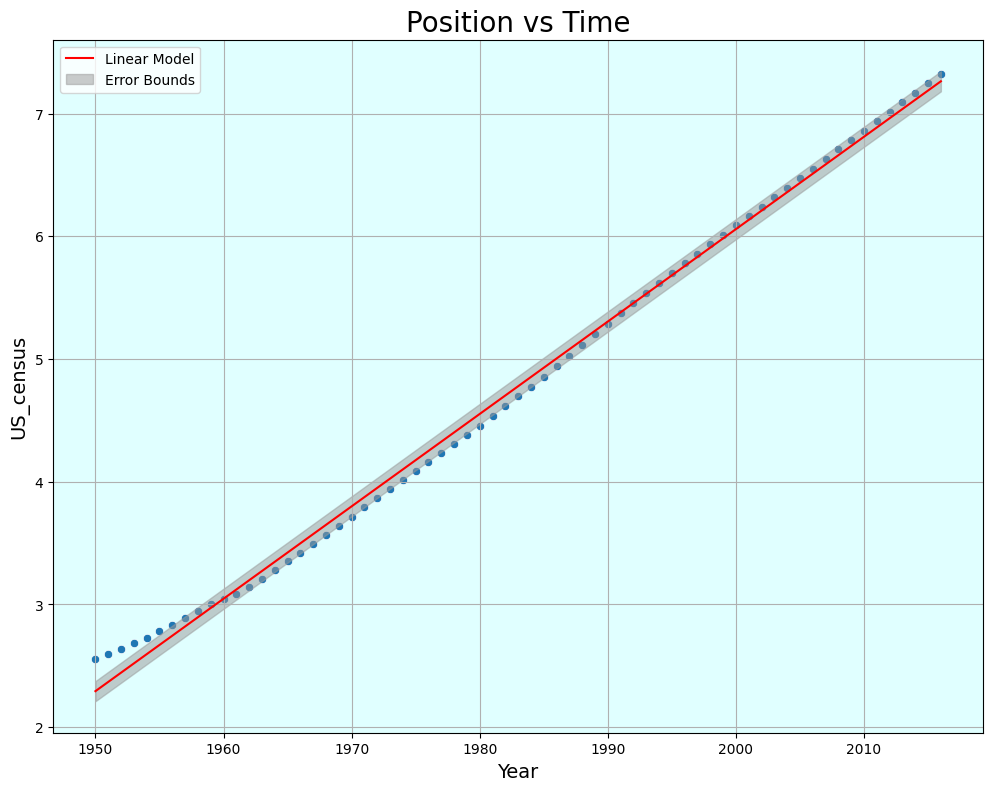

In [ ]:
##=============================================================================================##
## Create the Model and Get the Results and Predictions:                                       ##
##=============================================================================================##

linear_results, linear_predictions = create_model(X, y, "Linear", bias_on = True)

##=============================================================================================##
## Display The Results:                                                                        ##
##=============================================================================================##

# Set the model names:

name_list = [linear_results["Name"][0]]

# Set the coefficient(s) list:

coef_list = [linear_results["Coefs"][0]]

# Set the bias list:

bias_list = [linear_results["Bias"][0]]

# Set the loss list:

loss_list = [linear_results["Loss"][0]]

# Display the results:

display_model(name_list, coef_list, bias_list, loss_list, "Models")

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the title of the plot:

title = "Position vs Time"

# Set the x-axis and y-axis labels:

x_label = "Year"
y_label = "US_census"

# Create the model, color, and label lists:

model_list = [linear_predictions]
color_list = ["red"]
label_list = ["Linear Model"]

# Create a scatterplot of the feature data vs the target data:

graph = plot_data(X[x_label], y[y_label], title, [x_label, y_label], model_list, color_list,
                  label_list, error_display = True, error = loss_list[-1])

[Return to Top](#Notebook-Start)

<a name="Setup"></a>

---

<font size = 6> <b> 4. Simulation Setup</b> </font>

---

Even though, we can tell that the linear model isn't the best fit for the data, let's keep with it for now and create a simulation based on the linear model and see how it compares to the data and regression fitting. We start with the slope given to us by our regression model: 0.08.

<font size = 5> <b> 4.1 Define State Object </b> </font>

In [ ]:
##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

initial_state = pd.Series({
    "Population" : y.iloc[0].values[0],
    "Year"       : X.iloc[0].values[0]
})

initial_state.name = 'population'

display_dataframes([initial_state],["Initial State"])

,population
Population,2.557629
Year,1950.000000


<center>$\rule$</center>

<font size = 5> <b> 4.2 Define Simulation Parameters </b> </font>

In [ ]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the end year:

end_year = X.iloc[-1].values[0]

# Step Size:

step_size = 1 # year

# Growth Rate:

growth_rate = coef_list[0][0]

# Store the parameters in a dictionary:

parameters = pd.Series({
    "End Year"    : end_year,
    "Step Size"   : step_size,
    "Growth Rate" : growth_rate
})

# Rename the columns:

parameters.name = 'Value'

parameters.index.name = "Parameter"

# Display the Parameters:

display_dataframes([parameters],["Parameters"])

,Value
Parameter,
End Year,2016.00
Step Size,1.00
Growth Rate,0.08


<center>$\rule$</center>

<font size = 5> <b> 4.3 Create A Change Function </b> </font>

In [ ]:
##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

def change_function(state, growth_rate, step_size):

  # Update the ball's velocity, based on the acceleration and the size of the time step:

  state['Population'] += growth_rate * step_size

  # Update the simulation time:

  state['Year'] += step_size

  # Return the updated system state:

  return state

<center>$\rule$</center>

<font size = 5> <b> 4.3 Create A Simulation Function </b> </font>

In [ ]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters, initial_state):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end year:

  end_year = parameters.loc['End Year']

  # Get the step size:

  step_size = parameters.loc['Step Size']

  # Get the growth rate:

  growth_rate = parameters.loc['Growth Rate']

  # Calculate the number of simulation steps:

  n_steps = int((end_year - initial_state['Year']) / step_size)

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'World Population Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(n_steps):

    # Get the state of the system for the current time step:

    state = change_function(state, growth_rate, step_size)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

In [ ]:
##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation(state_history, X, y, plot_data = False, display_data = False):

  ##===========================================================================================##
  ## Compute the Simulation Loss:                                                              ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, simulation_history['Population']))

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display_data == True):

    # Create DataFrame to display the simulation loss:

    loss_df = pd.Series({"RMSE (Billion People)" : np.round(loss, 2)}).to_frame().T

    # Recombine the target and feature data:

    data = pd.concat([y, X], axis = 1)

    # Create a Dataframe containing the Real and Simulated Data:

    combined_df = pd.concat([y, state_history['Population'], X], axis = 1).dropna()

    combined_df.rename(columns = {'US_census' : 'Real Data', 'Population' : 'Simulated Data'},
                       inplace = True)

    # View the system's state history and final state:

    display_dataframes([data, state_history, loss_df],["Real Data", "State History", "Loss"])

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot_data == True):

    # Create the plot of the DataFrame:

    ax = combined_df.plot(
        #kind    = 'scatter',
        y       = ['Real Data', 'Simulated Data'],
        x       = 'Year',
        color   = ['red', 'blue'],
        figsize = (10, 6)
    )

    # Add titles and labels to the plot:

    ax.set_title("Population Vs. Time", fontsize = 14)

    ax.set_xlabel("Year", fontsize = 12)

    ax.set_ylabel("Population (in billions)", fontsize = 12)

    # Add grid and legend:

    plt.grid(True, linestyle = '--', alpha=0.5)

    # Set the legend's visibility to False

    #plt.legend().set_visible(False)

    plt.tight_layout()

    # Display the plot:

    plt.show()

  ##===========================================================================================##
  ## Return the Simulation Loss:                                                               ##
  ##===========================================================================================##

  return loss

,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.637629,1951.0
2,2.717629,1952.0
3,2.797629,1953.0


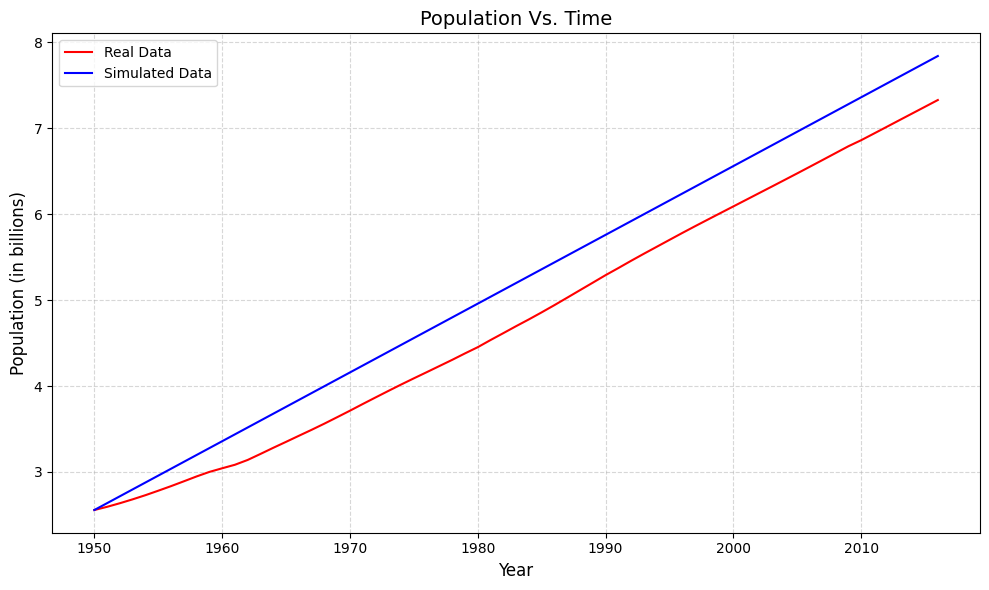

In [ ]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters, initial_state)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

We see that this RMSE is a bit higher than we saw with the curve fitting model. This is because the curve fitting model best-fit the data by not starting at the first data point (as we did in our simulation). Let's adjust down our slope to get a better result.

In [ ]:
slope = (y.iloc[-1].values[0] - y.iloc[0].values[0]) / (X.iloc[-1].values[0] - X.iloc[0].values[0])

print(slope)

0.07224800083333333


Now, let's use this new slope and see if we get a better result.

In [ ]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the end year:

end_year = 2016

# Step Size:

step_size = 1 # year

# Growth Rate:

growth_rate = float(slope)

# Store the parameters in a dictionary:

parameters_updated = pd.Series({
    "End Year"    : end_year,
    "Step Size"   : step_size,
    "Growth Rate" : growth_rate
})

parameters_updated.name = 'value'

display_dataframes([parameters_updated],["Parameters"])

,value
End Year,2016.000000
Step Size,1.000000
Growth Rate,0.072248


,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.629877,1951.0
2,2.702125,1952.0
3,2.774373,1953.0


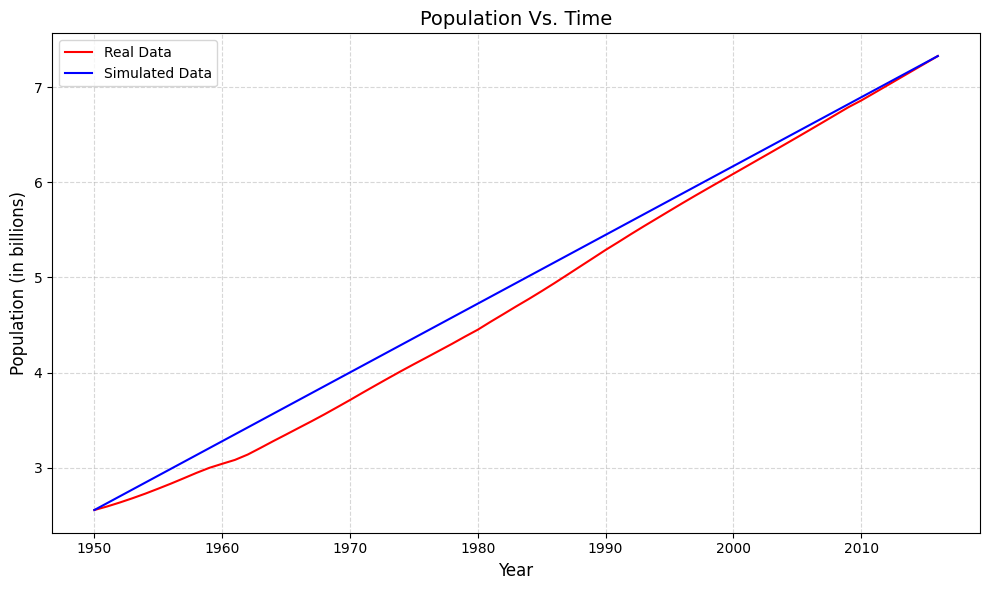

In [ ]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_updated, initial_state)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

[Return to Top](#Notebook-Start)

<a name="Search"></a>

---

<font size = 6> <b> 5. Parameter Search</b> </font>

---

<font size = 5> <b> 5.1 Find the Best-Fit Slope </b> </font>

In [ ]:
##=============================================================================================##
## Create a List of Slopes:                                                                    ##
##=============================================================================================##

# Set the first slope to test:

first_slope = 0.06

# Set the last slope to test:

last_slope = 0.08

# Set the number of slopes to test:

n_slopes = 100

# Create a numpy array of slopes:

slopes = np.linspace(first_slope, last_slope, n_slopes)

##=============================================================================================##
## Loop Through Slope Values:                                                                  ##
##=============================================================================================##

# Create a list to store the loss values:

loss_list = []

for slope in slopes:

  # Generate the parameters Series:

  parameters = pd.Series({
    "End Year"    : end_year,
    "Step Size"   : step_size,
    "Growth Rate" : slope
  })

  # Run the simulation:

  simulation_history = run_simulation(parameters, initial_state)

  # Analyze the simulation output:

  loss = analyze_simulation(simulation_history, X, y, plot_data = False, display_data = False)

  # Store the current loss:

  loss_list.append(loss)

##=============================================================================================##
## Store Slopes and Loss in DataFrame:                                                         ##
##=============================================================================================##

slope_loss_df = pd.DataFrame({"Slope" : slopes, "Loss" : loss_list})

# Display the DataFrame:

display_dataframes([slope_loss_df], ["Slope Loss DataFrame"])

##=============================================================================================##
## Use the Query Function to Get the Slope with the Smallest Loss:                             ##
##=============================================================================================##

best_slope = slope_loss_df.query('Loss == Loss.min()')['Slope'].values[0]
best_loss = slope_loss_df.query('Loss == Loss.min()')['Loss'].values[0]

print()
print("Best-Fit Slope: ", np.round(best_slope, 5))
print("Best-Fit Loss:", np.round(best_loss, 5))

,Slope,Loss
0,0.060000,0.390032
1,0.060202,0.382968
2,0.060404,0.375931
3,0.060606,0.368922
4,0.060808,0.361942



Best-Fit Slope:  0.06929
Best-Fit Loss: 0.15675


In [ ]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the end year:

end_year = 2016

# Step Size:

step_size = 1 # year

# Growth Rate:

growth_rate = float(best_slope)

# Store the parameters in a dictionary:

parameters_updated = pd.Series({
    "End Year"    : end_year,
    "Step Size"   : step_size,
    "Growth Rate" : growth_rate
})

parameters_updated.name = 'value'

display_dataframes([parameters_updated],["Parameters"])

,value
End Year,2016.000000
Step Size,1.000000
Growth Rate,0.069293


,US_census,Year
0,2.557629,1950
1,2.594940,1951
2,2.636772,1952
3,2.682053,1953
4,2.730228,1954
Time Step,Population,Year
0,2.557629,1950.0
1,2.626922,1951.0
2,2.696215,1952.0
3,2.765507,1953.0


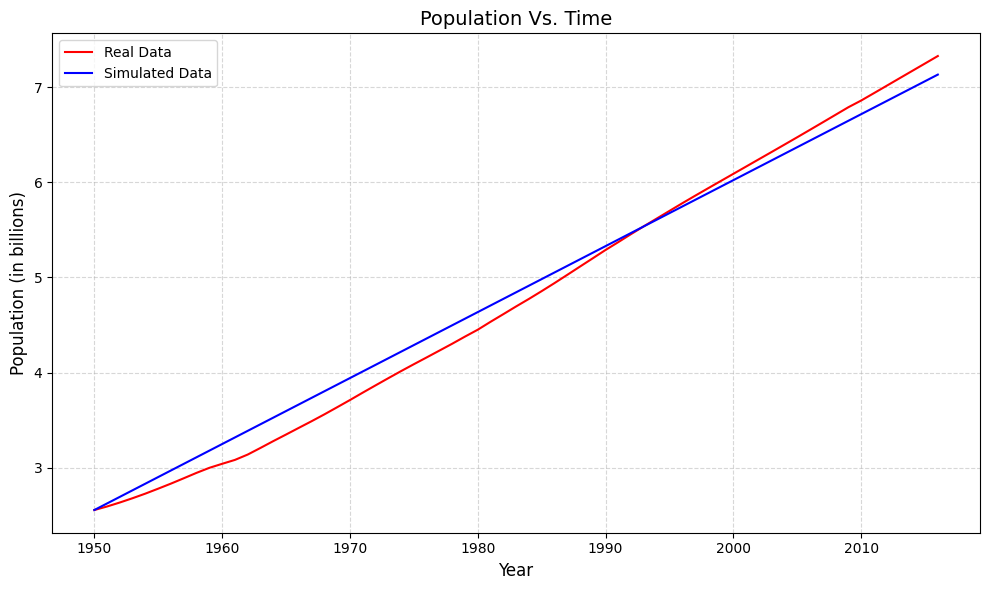

In [ ]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters_updated, initial_state)

##=============================================================================================##
## Analyze the Simulation:                                                                     ##
##=============================================================================================##

loss = analyze_simulation(simulation_history, X, y, plot_data = True, display_data = True)

[Return to Top](#Notebook-Start)

---